In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%load_ext rpy2.ipython

## Install R libraries

In [ ]:
%%R 

install.packages('Hmisc',depencies=TRUE,quiet=TRUE)
install.packages('patchwork',quiet=TRUE)
install.packages('gghalves',quiet=TRUE)
install.packages('here',quiet=TRUE)

install.packages("tidymodels",quiet=TRUE)
install.packages('tidytext',quiet=TRUE)
install.packages('plotly',quiet=TRUE)
install.packages('ggpubr',quiet=TRUE)
install.packages('GGally',quiet=TRUE)
install.packages('ggdist',quiet=TRUE)
install.packages('embed',quiet=TRUE)

In [ ]:
%%R

library(Hmisc)
library(here)
library(patchwork)
library(gghalves)
library(tidyverse)
library(tidymodels)
library(tidytext)
library(plotly)
library(ggpubr)
library(GGally)
library(ggdist)
library(embed)
library(here)
library(fs)

R[write to console]: Loading required package: lattice

R[write to console]: Loading required package: survival

R[write to console]: Loading required package: Formula

R[write to console]: Loading required package: ggplot2

R[write to console]: Keep up to date with changes at https://www.tidyverse.org/blog/

R[write to console]: 
Attaching package: ‘Hmisc’


R[write to console]: The following objects are masked from ‘package:base’:

    format.pval, units


R[write to console]: here() starts at /run/media/charly/MPB_DATA/Projects

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

R[write to console]: ✔ tibble  3.1.7     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1
✔ purrr   0.3.4     

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::src()       ma

## Setup directories

In [ ]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"
rootDir="/home/charly/Lab/Projects/SYNC_Projects/"

rootDir=rootDir+"pBGT/GIT/"
workingDir=rootDir+"code/Supplementary/"

data_path=rootDir+"data/uJ_data/"
fig_path=rootDir+"figures/SuppFigures/"
print(data_path)

%Rpush data_path
%Rpush fig_path


/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/data/uJ_data/


## Loading data

In [ ]:
%%R

#lineages_file <- here("data", "processed", "lineages.csv")
lineages_file <- paste(data_path, "processed_lineages.csv",sep="")

lineages_raw_df <- read_csv(
  file = lineages_file,
  show_col_types = FALSE
) %>%
  glimpse()

print(head(lineages_raw_df,2))
print(tail(lineages_raw_df,2))

Rows: 98,768
Columns: 21
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ filamented_at_time            <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ survived                      <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, …
$ antibiotic_end_time           <dbl> 100, 100, 100, 100, 100, 100, 100, 100, …
$ time         

In [ ]:
%%R
lineages_processed_1_df <- lineages_raw_df %>%
  mutate(
    filamented_id = factor( x = filamented_id,levels = c(FALSE, TRUE),labels = c("Not filamented", "Filamented")),
    filamented_at_time = factor(x = filamented_at_time,levels = c(FALSE, TRUE),labels = c("Not filamented", "Filamented")),
    survived = factor(x = survived,levels = c(FALSE, TRUE),labels = c("Not survived", "Survived")),
    cell_status = interaction(filamented_id,survived,sep = " - ") 
    %>% as.character() %>% as.factor()) %>%
glimpse()

Rows: 98,768
Columns: 22
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ filamented_at_time            <fct> Not filamented, Filamented, Not filament…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <fct> Filamented, Filamented, Filamented, Fila…
$ survived                      <fct> Survived, Survived, Survived, Survived, …
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, …
$ antibiotic_end_time           <dbl> 100, 100, 100, 100, 100, 100, 100, 100, …
$ time         

In [ ]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank()))

In [ ]:
%%R
status_time_df <- lineages_processed_1_df %>%
  select(experiment_id, id, time) %>%
  group_by(experiment_id) %>%
  group_modify(~ complete(expand(.x, id, time))) %>%
  ungroup() %>%
  left_join(lineages_processed_1_df) %>%
  rename(cell_status_at_time = filamented_at_time) %>%
  fill(time_first, time_last, gfp_first, filamentation_threshold, ds_red_threshold, .direction = "up") %>%
  fill(antibiotic_start_time, antibiotic_end_time, .direction = "down") %>%
  filter(time >= time_first) %>%
  mutate(
    cell_status_at_time = as.character(cell_status_at_time),
    cell_status_at_time = replace_na(cell_status_at_time, "Dead"),
    cell_status_at_time = factor(
      x = cell_status_at_time,
      levels = c("Not filamented", "Filamented", "Dead")
    ),
    time = factor(time)
  ) %>%
  glimpse() %>%
  identity()

Joining, by = c("experiment_id", "id", "time")
Rows: 166,866
Columns: 22
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ time                          <fct> 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 1…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ cell_status_at_time           <fct> Not filamented, Filamented, Not filament…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <fct> Filamented, Filamented, Filamented, Fila…
$ survived                      <fct> Survived, Survived, Survived, Survived, …
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 6

### pop lvl

In [ ]:
%%R
data_dir <- here(data_path)

cells_file <- paste(data_path, "cells_summary.csv",sep="")
cells_raw_df <- read_csv(
  file = cells_file,
  show_col_types = FALSE
) %>% 
  select(-over_ds_red_id) %>%
  rename(divided = divided_id)

print(head(cells_raw_df,2))
tail(cells_raw_df,n=c(2))

# A tibble: 2 × 25
  experiment_id id               divided_once_ex… filamented_id divided survived
  <chr>         <chr>            <lgl>            <lgl>         <lgl>   <lgl>   
1 Chromosome    xy01_1_10.008-3… TRUE             TRUE          TRUE    TRUE    
2 Chromosome    xy01_1_11.006-2… FALSE            TRUE          TRUE    TRUE    
# … with 19 more variables: antibiotic_start_time <dbl>,
#   antibiotic_end_time <dbl>, filamentation_threshold <dbl>, time_first <dbl>,
#   time_sos <dbl>, time_last <dbl>, length_first <dbl>, length_sos <dbl>,
#   length_last <dbl>, gfp_first <dbl>, gfp_sos <dbl>, gfp_last <dbl>,
#   ds_red_first <dbl>, ds_red_sos <dbl>, ds_red_last <dbl>, n_divisions <dbl>,
#   time_since_last_division_to_experiment_start <dbl>, lived_time <dbl>,
#   dead_or_missing_at_time <dbl>
# A tibble: 2 × 25
  experiment_id id               divided_once_ex… filamented_id divided survived
  <chr>         <chr>            <lgl>            <lgl>         <lgl>   <lgl>   
1 Pla

In [ ]:
%%R
cells_df <- cells_raw_df %>% 
  mutate(
    filamented_id = factor(x = filamented_id,levels = c(FALSE, TRUE), labels = c("Not filamented", "Filamented")),
    survived = factor(x = survived,levels = c(FALSE, TRUE),labels = c("Not survived", "Survived")),
    cell_status = interaction(filamented_id,survived,sep = " - "),
    cell_status = paste0(filamented_id," - ",survived),
    cell_status = factor(cell_status)) %>% 
  relocate(where(is.character), where(is.factor), where(is.logical))


   [1] Survived     Survived     Survived     Survived     Survived    
   [6] Survived     Survived     Survived     Not survived Survived    
  [11] Survived     Survived     Survived     Survived     Survived    
  [16] Survived     Survived     Survived     Survived     Survived    
  [21] Survived     Survived     Not survived Not survived Not survived
  [26] Not survived Not survived Not survived Not survived Not survived
  [31] Not survived Not survived Not survived Not survived Not survived
  [36] Not survived Not survived Not survived Survived     Not survived
  [41] Not survived Not survived Not survived Not survived Not survived
  [46] Not survived Not survived Not survived Not survived Not survived
  [51] Not survived Survived     Not survived Not survived Not survived
  [56] Not survived Not survived Not survived Not survived Not survived
  [61] Not survived Not survived Not survived Not survived Survived    
  [66] Not survived Not survived Not survived Not survived Not s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



### addictional functions

In [ ]:
%%R
parse_metrics_column <- function(.data, metric_column) {
  .data %>% 
    mutate(
      {{ metric_column }} := str_remove(
        string = {{ metric_column }},
        pattern = "(.+)_"
      ) %>% 
        factor(
          levels = c("first", "sos", "last"),
          labels = c("Initial", "SOS", "End")
        ) %>%
        identity()
    )
}

cell_status_pallete <- list(
    "Filamented - Not survived" = "#dd5129", 
    "Filamented - Survived" = "#0f7ba2", 
    "Not filamented - Survived" = "#43b284", 
    "Not filamented - Not survived"= "#fab255")

cell_status_legend_order <- c(
    "Not filamented - Survived",
    "Not filamented - Not survived",
    "Filamented - Survived",
    "Filamented - Not survived"
)

## Plotting Fig S4

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-4.pdf"


R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: `geom_smooth()` using formula 'y ~ x'

R[write to console]: `geom_smooth()` using formula 'y ~ x'



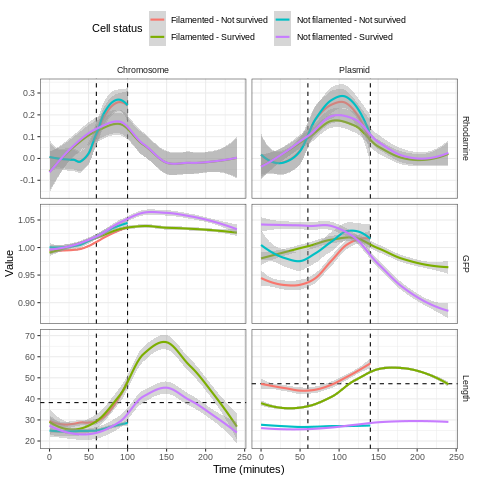

In [ ]:
%%R
p_metrics_over_time <- lineages_processed_1_df %>%
  select(experiment_id, cell_status, time, length, gfp, ds_red) %>%
  pivot_longer(
    cols = c(length, gfp, ds_red),
    names_to = "metric"
  ) %>%
  mutate(
    metric = case_when(
      metric == "ds_red" ~ "Rhodamine",
      metric == "gfp" ~ "GFP",
      metric == "length" ~ "Length"
    ),
    filamentation_threshold = ifelse(metric == "length", filamentation_threshold, NA)
  ) %>%
  group_by(experiment_id, cell_status, time, metric) %>%
  summarise(
    ci = list(mean_cl_normal(value)),
    .groups = "drop"
  ) %>%
  unnest(cols = c(ci)) %>%
  left_join(
    y = lineages_processed_1_df %>%
      select(experiment_id, antibiotic_start_time, antibiotic_end_time, filamentation_threshold) %>%
      distinct(),
    by = c("experiment_id")
  ) %>%
  mutate(
    filamentation_threshold = ifelse(metric == "Length", filamentation_threshold, NA)
  ) %>%
  mutate(metric = factor(metric, levels = c("Rhodamine", "GFP", "Length"))) %>%   #<-------------------- change plot order
  ggplot(aes(x = time, y = y, ymin = ymin, ymax = ymax, color = cell_status)) +
  geom_vline(aes(xintercept = antibiotic_start_time), linetype = "dashed") +
  geom_vline(aes(xintercept = antibiotic_end_time), linetype = "dashed") +
  geom_hline(aes(yintercept = as.numeric(filamentation_threshold)), linetype = "dashed") +
  geom_smooth(method = "loess") +
  facet_grid(metric ~ experiment_id, scales = "free_y") +
  labs(
    x = "Time (minutes)",
    y = "Value",
    color = "Cell status"
  ) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  NULL



figname=paste(fig_path,"sFig-4.pdf",sep="")
print(figname)
ggsave(figname, plot = p_metrics_over_time)
p_metrics_over_time

## Plotting Figure S6

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-6.pdf"


R[write to console]: Saving 6.67 x 6.67 in image



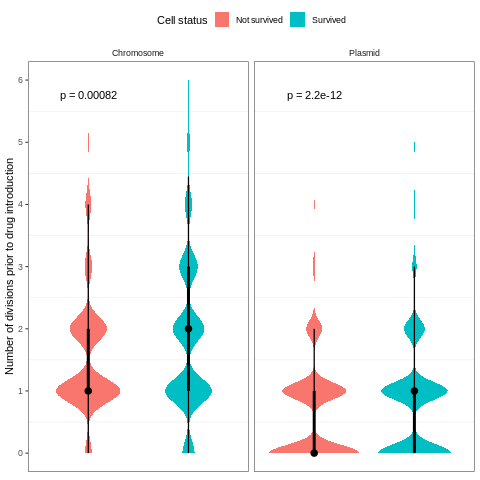

In [ ]:
%%R


ndivs_p_a <- lineages_processed_1_df |> 
    filter(
        time <= antibiotic_start_time
    ) |> 
    count(experiment_id, id, survived, wt = division) |> 
    ggplot(aes(
        x = survived,
        y = n,
        fill = survived  
    )) +
    stat_eye() +
    #stat_eye(position = "dodge") +
    stat_compare_means(
      label = "p.format",
      method = "t.test",
      ref.group = "Survived",
      label.y.npc = 0.95,
      hide.ns = TRUE
    ) +
    # stat_compare_means(
    #   method = "t.test",
    #   #comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    #   comparisons = list(c("Not Survived", "Survived")),
    #   label = "p.signif",
    #   label.y.npc = 0.6,
    #   hide.ns = TRUE
    # ) +
    facet_grid(. ~ experiment_id) +
    guides(
      fill = guide_legend(ncol = 2)
    ) +
    theme(
      panel.grid.major = element_blank(),
      axis.text.x = element_blank(),
      axis.title.x = element_blank(),
      axis.ticks.x = element_blank(),
      panel.grid = element_line(colour = "grey92"),
      panel.grid.minor = element_line(size = rel(0.5))
    ) +
    # scale_fill_manual(
    #   values = cell_status_pallete,
    #   breaks = cell_status_legend_order
    # ) +
    scale_y_continuous(
        breaks = 0:6
    ) +
    labs(
      y = "Number of divisions prior to drug introduction",
      fill = "Cell status"
    ) +
    NULL

figname=paste(fig_path,"sFig-6.pdf",sep="")
print(figname)
ggsave(figname, plot = ndivs_p_a)
ndivs_p_a


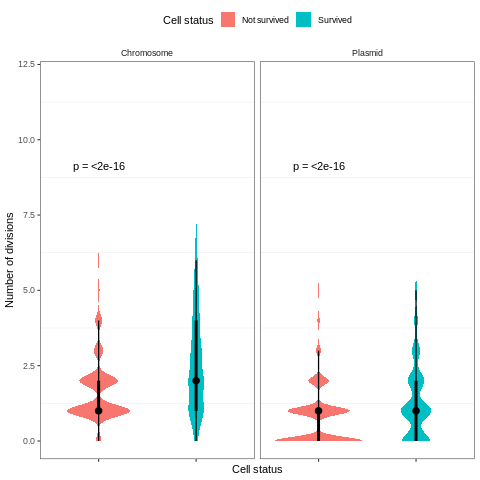

In [ ]:
%%R  
#############This plot is not prior to antibiotic
p_number_divisions <-cells_df %>% 
  ggplot(aes(x = survived, y = n_divisions, fill = survived)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.format",
    method = "t.test",
    ref.group = "Survived",
    label.y.npc = 0.75,
    hide.ns = TRUE
  ) +

  facet_grid(. ~ experiment_id) +
  #coord_cartesian(ylim = c(0, 10)) +
  guides(
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    panel.grid.major = element_blank(),
    axis.text.x = element_blank()
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions",
    fill = "Cell status"
  ) +
  NULL

p_number_divisions

## Plotting Figure S7

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-7.pdf"


R[write to console]: Saving 6.67 x 6.67 in image



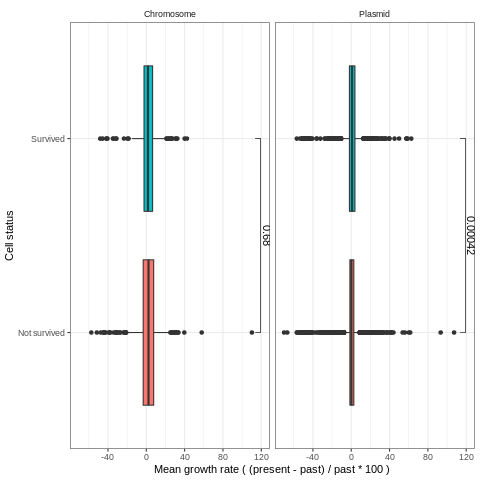

In [ ]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank() ))

elongation_rates_dt <- lineages_processed_1_df %>% 
  select(experiment_id,
         id,
         survived,
         length,
         time,
         antibiotic_start_time,
         time_last
  ) %>% 
  filter(time <= time_last, time < antibiotic_start_time) %>% 
  arrange(experiment_id
          , id
          , time
  ) %>% 
  group_by(experiment_id,
           id,
           survived
  ) %>% 
  mutate(
    growth_rate = (length - lag(length)) / lag(length) * 100
  ) %>% 
  dplyr::summarize(
    mean_growth_rate = mean(growth_rate, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  ggplot(aes(x = survived, y = mean_growth_rate, fill = survived)) +
  geom_boxplot() +
  ggpubr::stat_compare_means(
    method = "t.test",
    comparisons = list(c("Survived", "Not survived"))
  ) +
  facet_grid(. ~ experiment_id) +
  coord_flip() +
  labs(
    x = "Cell status",
    y = "Mean growth rate ( (present - past) / past * 100 )"
  ) +
  theme(legend.position = "none") +
  NULL

elongation_rates_dt

figname=paste(fig_path,"sFig-7.pdf",sep="")
print(figname)
ggsave(figname, plot = elongation_rates_dt)
elongation_rates_dt

## Plotting Figure S8  check & aspect ratio

In [ ]:
%%R
cell_status_pallete <- list(
    "Filamented - Not survived" = "#dd5129", 
    "Filamented - Survived" = "#0f7ba2", 
    "Not filamented - Survived" = "#43b284", 
    "Not filamented - Not survived"= "#fab255")

cell_status_legend_order <- c(
    "Not filamented - Survived",
    "Not filamented - Not survived",
    "Filamented - Survived",
    "Filamented - Not survived"
)

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-8.pdf"


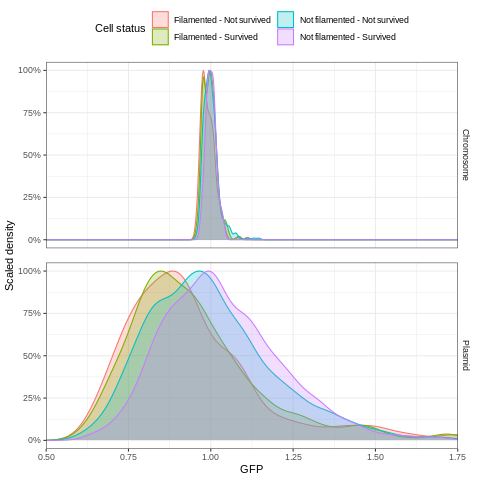

In [ ]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank() ))


pdists <- cells_df |> 
  ggplot(aes(
    #x = (gfp_first-mean(gfp_first))/sd(gfp_first),
    x = gfp_first,
    y = ..scaled..,
    color = cell_status,
    fill = cell_status
  )) +
  geom_density(
    alpha = 1/4,
  ) +
  facet_grid(experiment_id ~ .) +
  scale_x_continuous(
    expand = c(0, 0),
    limits= c(.5,1.75)
  ) +
  scale_y_continuous(
    expand = c(0, .05),
    labels = scales::label_percent()
  ) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    legend.position = "top",
    panel.spacing = unit(1, "lines")
  ) +
  labs(
    x = "GFP",
    y = "Scaled density",
    color = "Cell status",
    fill = "Cell status"
  ) +
#  scale_fill_manual(
#      values = cell_status_pallete,
#      breaks = cell_status_legend_order
# ) +
#   scale_color_manual(
#       values = cell_status_pallete,
#       breaks = cell_status_legend_order
#   ) +
  NULL

aspect_ratio <- 2
height <- 5
#ggsave(g, height = height , width = height * aspect_ratio)
figname=paste(fig_path,"sFig-8.pdf",sep="")
print(figname)
ggsave(figname, plot = pdists,height = height , width = height * aspect_ratio)
pdists

## Plotting Figure S9  check!

 ### S9 A

In [ ]:
%%R
experiment_datasets <- cells_df %>% 
  select(experiment_id, cell_status, divided, contains("first"), contains("last"), -contains("time")) %>% 
  mutate(divided = as.numeric(divided)) %>% 
  select(where(~!any(is.na(.)))) %>% 
  glimpse() %>% 
  
  group_by(experiment_id) %>% 
  {
    grouped_data <- .
    group_split(grouped_data) %>% 
      set_names(nm = group_keys(grouped_data) %>% pull())
  } %>% 
  map(select, -experiment_id) %>% 
  identity()
chromosome_df <- experiment_datasets$Chromosome
plasmid_df <- experiment_datasets$Plasmid

c_pca_rec <- recipe(cell_status ~ ., data = chromosome_df) %>% 
  step_naomit(all_predictors()) %>% 
  step_normalize(all_predictors()) %>%
  step_pca(all_predictors())
set.seed(42)
c_pca_prep <- prep(c_pca_rec)
c_pca_prep


p_pca_rec <- recipe(cell_status ~ ., data = plasmid_df) %>% 
  step_naomit(all_predictors()) %>% 
  step_normalize(all_predictors()) %>%
  step_pca(all_predictors())
set.seed(42)
p_pca_prep <- prep(p_pca_rec)
p_pca_prep

Rows: 6,887
Columns: 9
$ experiment_id <chr> "Chromosome", "Chromosome", "Chromosome", "Chromosome", …
$ cell_status   <fct> Filamented - Survived, Filamented - Survived, Filamented…
$ divided       <dbl> 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ length_first  <dbl> 25.84965, 41.41517, 29.75801, 34.05492, 30.65443, 34.123…
$ gfp_first     <dbl> 0.9840791, 0.9855457, 0.9737886, 0.9694626, 0.9717567, 0…
$ ds_red_first  <dbl> 0.0061646271, 0.0064229106, 0.0013001476, -0.0027127884,…
$ length_last   <dbl> 36.53545, 85.05345, 89.14717, 64.49689, 81.95718, 49.423…
$ gfp_last      <dbl> 0.9783849, 0.9837842, 0.9779097, 0.9806626, 0.9792288, 0…
$ ds_red_last   <dbl> 0.0002056192, -0.0004813917, -0.0015964676, -0.001680148…
Recipe

Inputs:

      role #variables
   outcome          1
 predictor          7

Training data contained 5810 data points and no missing data.

Operations:

Removing rows with NA values in divided, length_first, gfp_first, ds_red_first,... [trained]
Cent

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-9A.pdf"


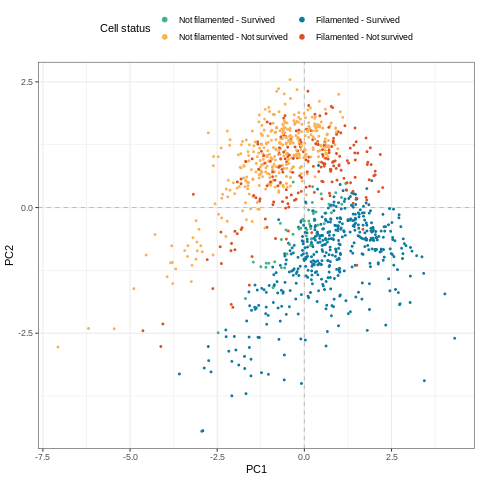

In [ ]:
%%R

p_c_pca <- c_pca_prep %>% 
  juice() %>% 
  ggplot(aes(x = PC1, y = PC2, color = cell_status)) +
  geom_vline(xintercept = 0, color = "gray", linetype = "dashed") +
  geom_hline(yintercept = 0, color = "gray", linetype = "dashed") +
  geom_jitter(size = 0.7, position = position_jitter(seed = 42)) +
  guides(
    color = guide_legend(ncol = 2, override.aes = list(alpha = 1, size = 2)),
    fill = guide_legend(ncol = 2, override.aes = list(alpha = 1, size = 2))
  ) +
  labs(
    color = "Cell status"
  ) +
  scale_fill_manual(
      values = cell_status_pallete,
      breaks = cell_status_legend_order
  ) +
  scale_color_manual(
      values = cell_status_pallete,
      breaks = cell_status_legend_order
  ) + 
  NULL



aspect_ratio <- 1.25
height <- 5
#ggsave(g, height = height , width = height * aspect_ratio)
figname=paste(fig_path,"sFig-9A.pdf",sep="")
print(figname)
ggsave(figname, plot = p_c_pca,  height = height , width = height * aspect_ratio)

p_c_pca

 ### S9 B

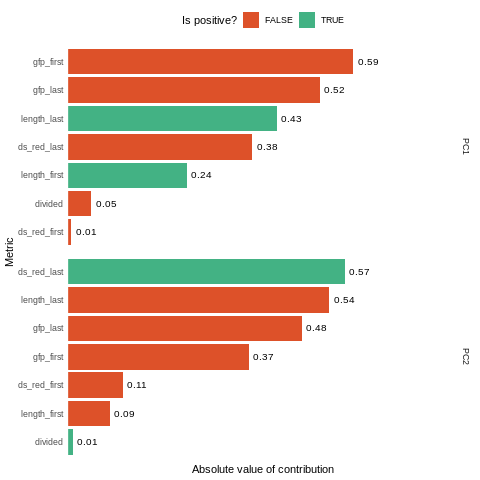

In [ ]:
%%R

# c_tidied_pca <- tidy(c_pca_prep, 3)
# p_c_titied_pca <- c_tidied_pca %>%
#   filter(component %in% paste0("PC", 1:2)) %>%
#   mutate(
#     component = fct_inorder(component),
#     terms = reorder_within(terms, abs(value), component)
#   ) %>%
#   ggplot(
#     aes(
#       x = abs(value), 
#       y= terms,
#       fill = value > 0
#     )
#   ) +
#   geom_bar(stat = "identity") +
#   geom_text(aes(label = round(abs(value), digits = 2)), hjust = -0.2, size = 3.5) +
#   facet_grid(component ~ ., scales = "free_y") +
#   scale_y_reordered() +
#   scale_x_continuous(
#       expand = c(0, 0),
#       limits = c(0, 0.8)
#   ) +
#   labs(
#     x = "Absolute value of contribution",
#     y = "Metric",
#     fill = "Is positive?"
#   ) +
#   theme_minimal() +
#   theme(
#       panel.grid = element_blank(),
#       legend.position = "top",
#       axis.ticks.y = element_blank(),
#       axis.text.x = element_blank()
#   ) +
#   scale_fill_manual(
#       values = c("#dd5129", "#43b284")
#   )
# p_c_titied_pca

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-9B.pdf"


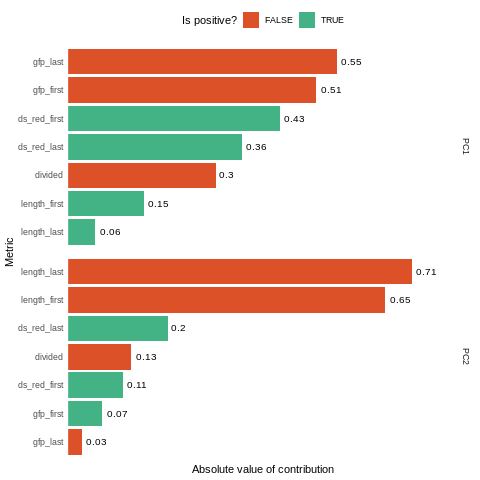

In [ ]:
%%R

p_tidied_pca <- tidy(p_pca_prep, 3)
p_p_titied_pca <- p_tidied_pca %>%
  filter(component %in% paste0("PC", 1:2)) %>%
  mutate(
    component = fct_inorder(component),
    terms = reorder_within(terms, abs(value), component)
  ) %>%
  ggplot(
    aes(
      x = abs(value), 
      y= terms,
      fill = value > 0
    )
  ) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = round(abs(value), digits = 2)), hjust = -0.2, size = 3.5) +
  facet_grid(component ~ ., scales = "free_y") +
  scale_y_reordered() +
  scale_x_continuous(
      expand = c(0, 0),
      limits = c(0, 0.8)
  ) +
  labs(
    x = "Absolute value of contribution",
    y = "Metric",
    fill = "Is positive?"
  ) +
  theme_minimal() +
  theme(
      panel.grid = element_blank(),
      legend.position = "top",
      axis.ticks.y = element_blank(),
      axis.text.x = element_blank()
  ) +
  scale_fill_manual(
      values = c("#dd5129", "#43b284")
  )



aspect_ratio <- 1.25
height <- 5
#ggsave(g, height = height , width = height * aspect_ratio)
figname=paste(fig_path,"sFig-9B.pdf",sep="")
print(figname)
ggsave(figname, plot = p_p_titied_pca,  height = height , width = height * aspect_ratio)


p_p_titied_pca

## Plotting Figure S10  fix colors

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-10A.pdf"


R[write to console]: `geom_smooth()` using method = 'loess' and formula 'y ~ x'

R[write to console]: `geom_smooth()` using method = 'loess' and formula 'y ~ x'



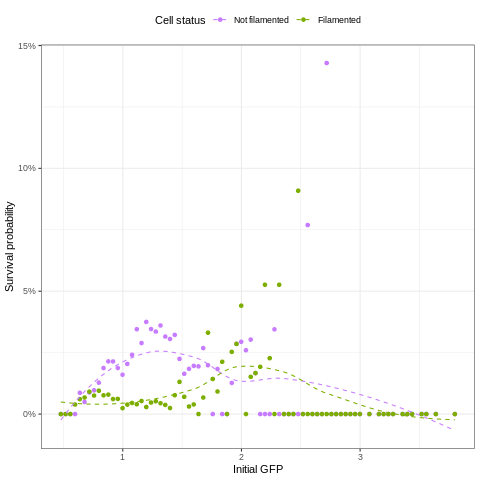

In [ ]:
%%R
step <- 0.04
breaks <- seq(min(lineages_processed_1_df$gfp) - step, max(lineages_processed_1_df$gfp) + step, step)
hist_gfp_control_info <- hist(
  lineages_processed_1_df$gfp,
  breaks = breaks,
  plot = FALSE
)
p_survival_probability_gfp <- lineages_processed_1_df %>%
  filter(experiment_id == "Plasmid", survived == "Survived", time == time_first) %>%
  group_by(filamented_id) %>%
  dplyr::summarize(
    counts = list(hist(gfp, plot = FALSE, breaks = breaks)$counts)
  ) %>%
  unnest(counts) %>%
  mutate(
    mids = rep(hist_gfp_control_info$mids, 2),
    control_counts = rep(hist_gfp_control_info$counts, times = 2),
    survival_probability = counts / control_counts
  ) %>%
  identity() %>%
  # filter(survival_probability != 0) %>%
  ggplot(aes(x = mids, y = survival_probability, color = filamented_id)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  scale_color_hue(direction = -1, h.start = 90) +
  labs(
    x = "Initial GFP",
    y = "Survival probability",
    color = "Cell status"
  )




aspect_ratio <- 1.25
height <- 5
#ggsave(g, height = height , width = height * aspect_ratio)
figname=paste(fig_path,"sFig-10A.pdf",sep="")
print(figname)
ggsave(figname, plot = p_survival_probability_gfp,  height = height , width = height * aspect_ratio)

p_survival_probability_gfp




[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-10B.pdf"


R[write to console]: `geom_smooth()` using method = 'loess' and formula 'y ~ x'

R[write to console]: `geom_smooth()` using method = 'loess' and formula 'y ~ x'



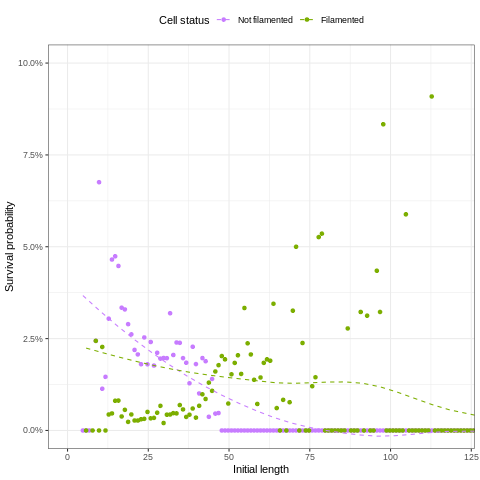

In [ ]:
%%R
step <- 1
breaks <- seq(min(lineages_processed_1_df$length) - step, max(lineages_processed_1_df$length) + step, step)
hist_length_control_info <- hist(
  lineages_processed_1_df$length,
  breaks = breaks,
  plot = FALSE
)

survival_probability_length <- lineages_processed_1_df %>%
  filter(experiment_id == "Plasmid", survived == "Survived", time == time_first) %>%
  group_by(filamented_id) %>%
  dplyr::summarize(
    counts = list(hist(length, plot = FALSE, breaks = breaks)$counts)
  ) %>%
  unnest(counts) %>%
  mutate(
    mids = rep(hist_length_control_info$mids, 2),
    control_counts = rep(hist_length_control_info$counts, times = 2),
    survival_probability = counts / control_counts
  ) %>%
  identity()

p_survival_probability_length <- survival_probability_length %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability, color = filamented_id)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  scale_color_hue(direction = -1, h.start = 90) +
  labs(
    x = "Initial length",
    y = "Survival probability",
    color = "Cell status"
  ) +
  coord_cartesian(
    xlim = c(FALSE, 120),
    ylim = c(0, 0.1)
  )

aspect_ratio <- 1.25
height <- 5
figname=paste(fig_path,"sFig-10B.pdf",sep="")
print(figname)
ggsave(figname, plot = p_survival_probability_length,  height = height , width = height * aspect_ratio)
p_survival_probability_length

## Plotting Figure S11   aspect ratio


[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-11.pdf"


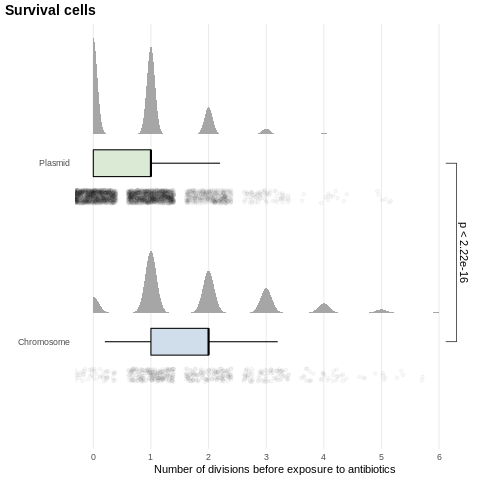

In [ ]:
%%R


p_n_divisions <- lineages_processed_1_df |>
  filter(time <= antibiotic_start_time, survived == "Survived") |>
  group_by(experiment_id, id) |>
  dplyr::summarize(
    n_divisions = sum(division),
    .groups = "drop"
  ) |>
  ggplot(
    aes(
      x = experiment_id,
      y = n_divisions
    )
  ) +
  ggdist::stat_halfeye(
    adjust = 0.5,
    width = 0.6,
    .width = 0,
    justification = -0.3,
    point_colour = NA
  ) +
  geom_boxplot(aes(
            color = experiment_id,
            fill = experiment_id),
    position = position_nudge(y = 0.2),
    width = 0.15,
    outlier.shape = NA
  ) +
  gghalves::geom_half_point(
    side = "l",
    range_scale = 0.2,
    alpha = 1 / 30
  ) +
  ggpubr::stat_compare_means(
    method = "t.test",
    comparisons = list(c("Plasmid", "Chromosome"))
  ) +
  scale_y_continuous(
    breaks = 0:6
  ) +
  scale_color_manual(
        values = c("black", "black")
    ) +
    scale_fill_manual(
        values = c("#D0DEEB", "#DAEAD5")
    ) +
  coord_flip() +
  theme_minimal() +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    legend.position = "none",
    plot.title.position = "plot",
    plot.title = element_text(
      face = "bold",
      size = 14,
      hjust = 0
    )
  ) +
  labs(
    x = "",
    y = "Number of divisions before exposure to antibiotics",
    title = "Survival cells"
  ) +
  NULL

aspect_ratio <- 2.5
height <- 5
figname=paste(fig_path,"sFig-11.pdf",sep="")
print(figname)
ggsave(figname, plot = p_n_divisions,  height = height , width = height * aspect_ratio)
p_n_divisions